Imports data from TN Julia simulation

In [18]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [19]:
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt

import matplotlib.lines as mlines
import matplotlib.patches as mpatches
from matplotlib.legend_handler import HandlerBase, HandlerTuple

import os
from math import comb
import json
from copy import copy

In [20]:
RASTERIZE = True

In [21]:
os.makedirs("../plots", exist_ok=True)

In [22]:
plt.style.use("default")
plt.style.use("../../../config/unified_plots.mplstyle")
plt.rcParams['savefig.bbox'] = None
with open("../../../config/unified_plots.json", "r") as f:
    plot_args = json.load(f)
plot_opt_args = plot_args['optimization']

### Specifcation of the Majorana system (and Majorana basis)

In [23]:
n = 55 # number of qubits
STATE_PREP = "OAT"
#STATE_PREP = "TAT"

In [24]:
# Load all Julia data:
sub_dir = f"{n}q"
O = np.load(f"../data/{sub_dir}/coeffs.npy")
feature_vecs = np.load(f"../data/{sub_dir}/feat_vec.npy")
outputs = np.load(f"../data/{sub_dir}/outputs.npy")
ts = np.load(f"../data/{sub_dir}/t_list.npy")
thetas = np.load(f"../data/{sub_dir}/theta_list.npy")

In [25]:
print(ts[0] - ts[1])

-0.006283185307179587


In [26]:
# Load all BO data:
# was saved via this code snipped
#np.savez_compressed(f"../data/opt_BO_QS_{n}q.npz",
#         logged_ts=logged_ts, logged_obs=logged_obs,
#                    logged_d_obs_pred=logged_d_obs_pred, logged_d_obs_std=logged_d_obs_std,
#                    opt_t=opt_t, opt_obs=opt_obs, opt_idx=opt_idx,)

bo_res = np.load(f"../results/results_{n}q_simplified.npz", allow_pickle=True)
logged_ts = bo_res["logged_ts"]
logged_obs = bo_res["logged_obs"]
logged_d_obs_pred = bo_res["logged_d_obs_pred"]
logged_d_obs_std = bo_res["logged_d_obs_std"]
logged_gp_preds = bo_res["logged_gp_preds"]
logged_gp_stds = bo_res["logged_gp_stds"]
logged_acquisition_vals = bo_res["logged_acquisition_vals"]
opt_t = bo_res["opt_t"]
opt_obs = bo_res["opt_obs"]
opt_idx = bo_res["opt_idx"]

In [27]:
n_skip = 1
n_skip_first = 0
n_skip_last = len(ts)
ts = ts[n_skip_first:n_skip_last:n_skip]
outputs = outputs[n_skip_first:n_skip_last:n_skip]
feature_vecs = feature_vecs[n_skip_first:n_skip_last:n_skip]

In [28]:
t_min, t_max = np.pi/8, 2*np.pi - np.pi/8
domain_mask = (t_min <= ts) & (ts <= t_max)
ts = ts[domain_mask]
outputs = outputs[domain_mask]
feature_vecs = feature_vecs[domain_mask]

In [29]:
# Infer the majorana system:
d = 2*n
# number of majoranas in the observable
for m in range(d):
    if comb(d, m) == feature_vecs.shape[-1]:
        break
print(f"Module B_{m}")
num_data_points = len(outputs)
n_params = ts.shape[-1] if ts.ndim > 1 else 1

Module B_2


In [30]:
bo_cmap = plt.colormaps.get_cmap("spring_r")

## Simplified BO of derivative 
***Here we use the fact that at theta=0, the observable commutes with the initial state, i.e., constant observation. Hence, equivalent to just maximize directly for small pertubation delta_theta under finite forward/backward differences approximation. Hence, no explicit derivative of GP needed.***

In [31]:
# Fix thetas:
theta_idx = len(thetas) // 2 + 5
theta_fixed_idx = len(thetas) // 2
delta_theta = np.abs(thetas[theta_idx] - thetas[theta_fixed_idx])
print(f"delta_theta = {delta_theta}, at {thetas[theta_idx]} (index {theta_idx})")

delta_theta = 0.05, at 0.05 (index 25)


In [32]:
orig_2d_outputs = np.load(f"../data/{sub_dir}/outputs.npy")[n_skip_first:n_skip_last:n_skip][domain_mask]
outputs = orig_2d_outputs[:, theta_idx]
d_outputs = outputs
print("Outputs shape:", outputs.shape)

Outputs shape: (875,)


In [33]:
def slope_to_tangent_line(slope, pos, tangent_len):
    # Compute direction vector (dx, dy) for the tangent
    dx = 1.0
    dy = slope * dx

    # Normalize to unit length
    norm = np.sqrt(dx**2 + dy**2)
    dx_unit = dx / norm
    dy_unit = dy / norm

    # Scale to half the tangent length (for both sides)
    dx_scaled = dx_unit * (tangent_len / 2)
    dy_scaled = dy_unit * (tangent_len / 2)

    # Endpoints of the tangent segment
    t_tangent = np.array([pos[0] - dx_scaled, pos[0] + dx_scaled])
    f_tangent = np.array([pos[1] - dy_scaled, pos[1] + dy_scaled])

    return t_tangent, f_tangent


t0_idx=437
GP plot range: 2.356 to 3.921
t0_idx=687
GP plot range: 3.927 to 5.492
t0_idx=452
GP plot range: 2.450 to 4.015
t0_idx=421
GP plot range: 2.256 to 3.820
t0_idx=273
GP plot range: 1.326 to 2.890
t0_idx=430
GP plot range: 2.312 to 3.877
t0_idx=460
GP plot range: 2.501 to 4.065


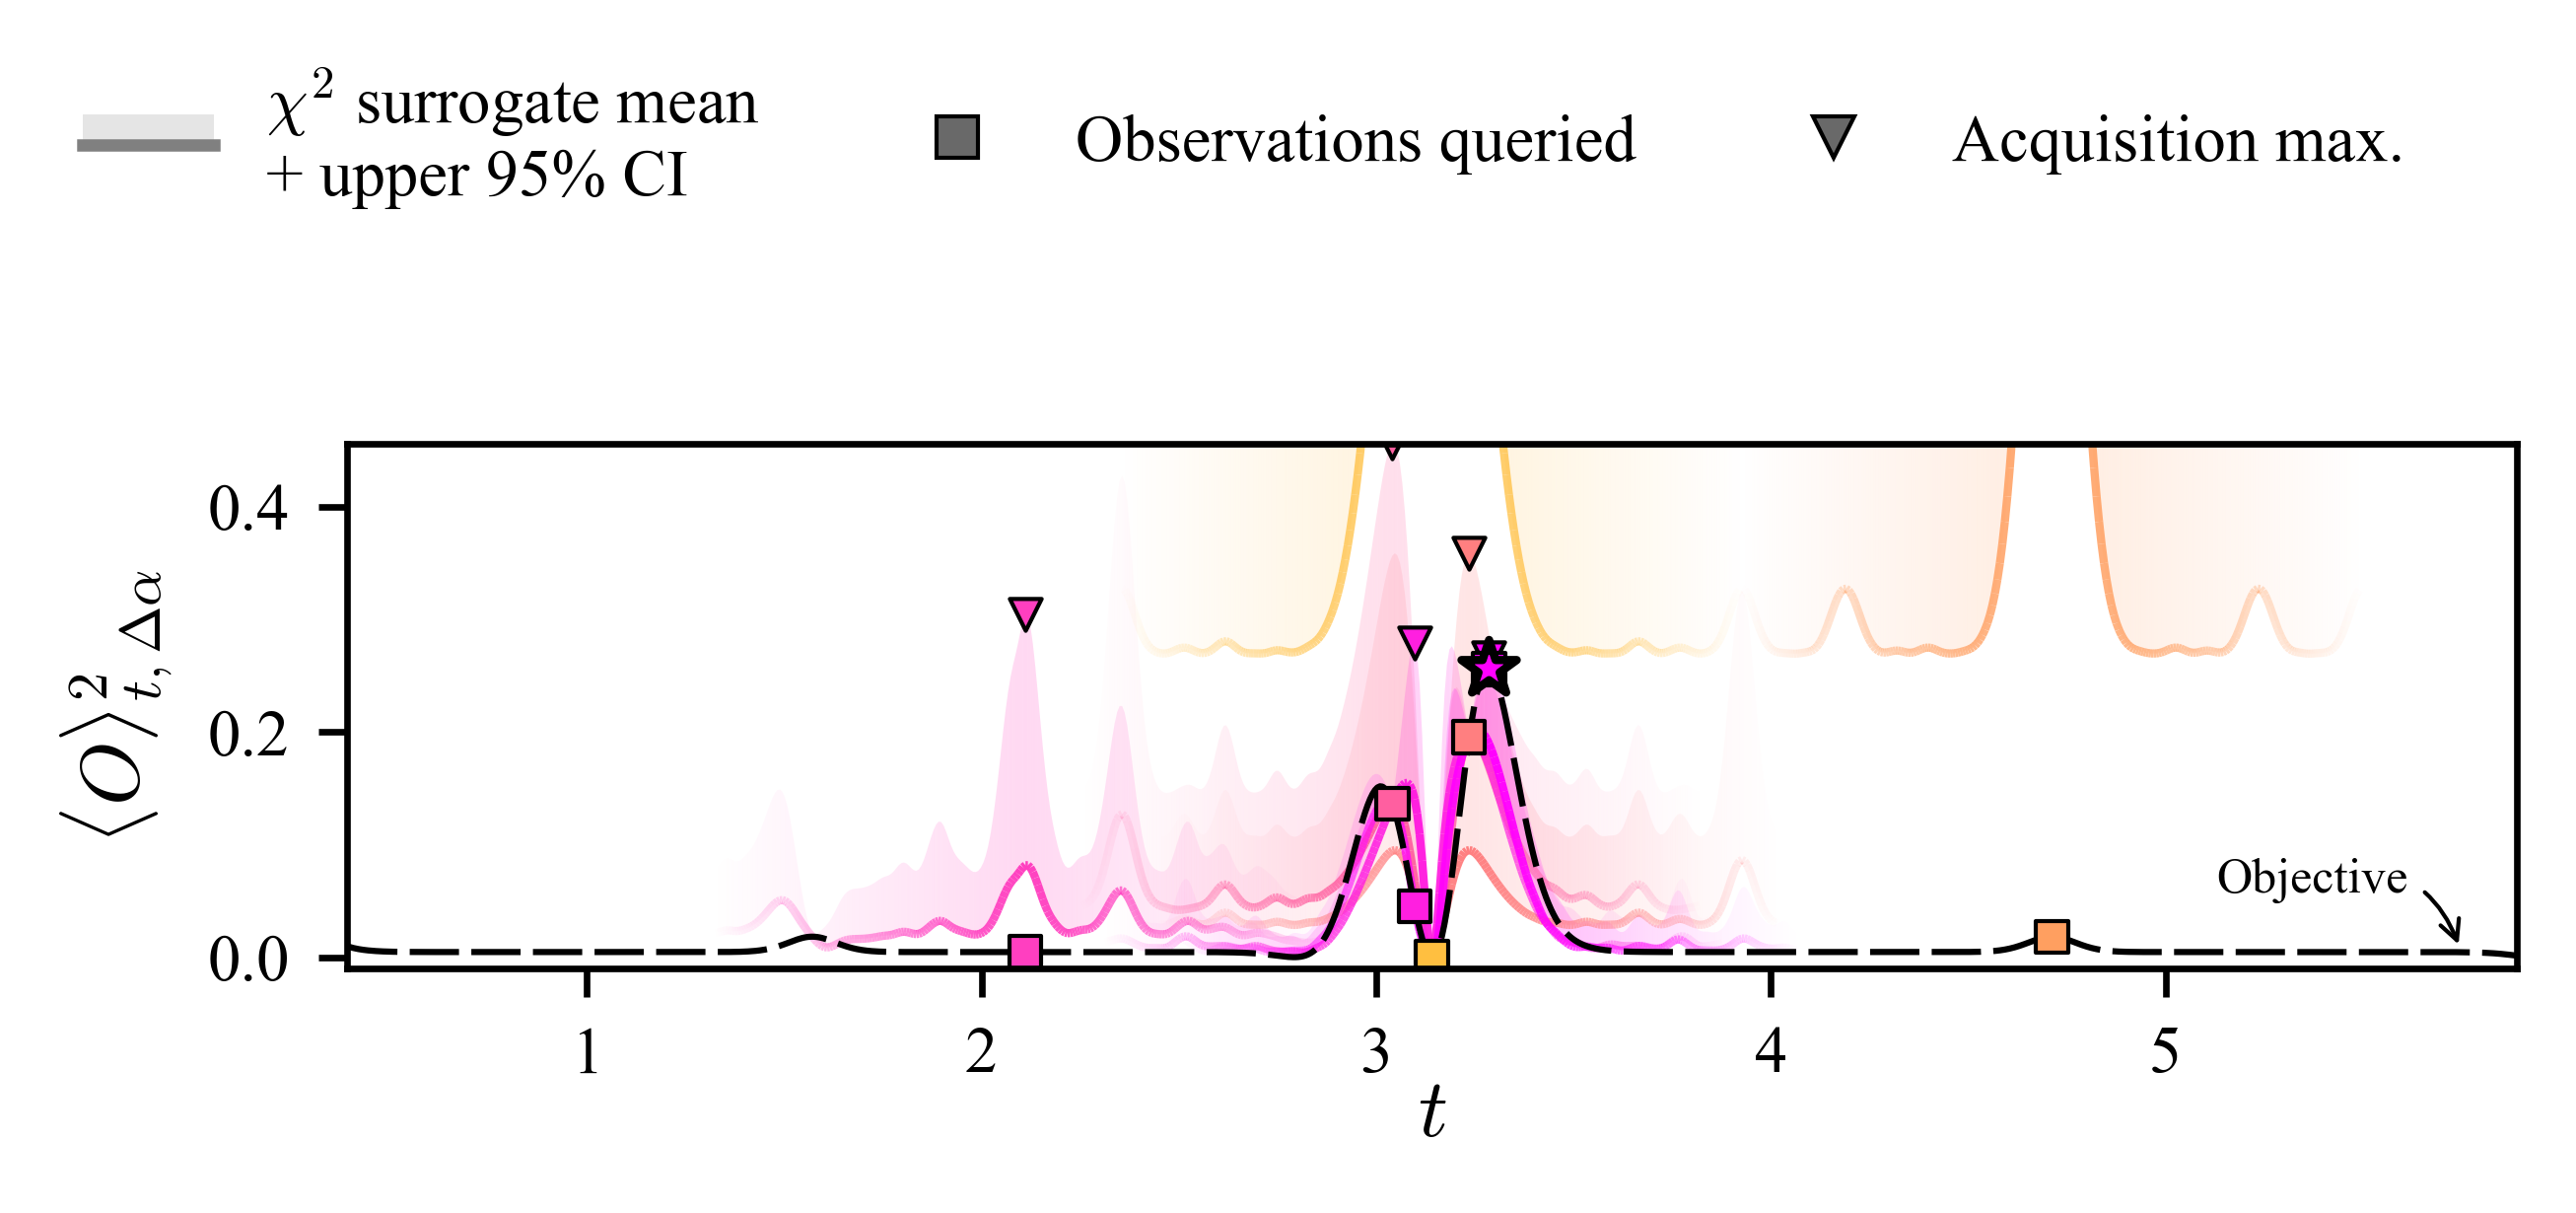

In [34]:
# Plot the data:
# Use different markers for training and test data:
W = plot_args['fig_width_inches_full']
fig = plt.figure(figsize=tuple(np.array((0.66*W, 2.))), dpi=600)
ax = fig.add_subplot(111)

objective_kwargs = copy(plot_args['true_function'])
objective_kwargs['zorder'] = 50
objective_kwargs['label'] = 'Objective'
plt.plot(ts, outputs**2, **objective_kwargs)

# Annotate the objective function
target_t = 5.75
target_idx = np.argmin(np.abs(ts - target_t))
target_val = outputs[target_idx]**2
plt.annotate(
    "Objective",
    xy=(target_t, target_val),          # Where the arrow POINTS
    xytext=(0.95, 0.125),     # Where the TEXT sits (fraction of the axes box)
    xycoords='data',
    textcoords='axes fraction',
    color='black',           # Matches your plt.plot(..., color='black')
    fontsize=6,
    ha='right',
    va='bottom',
    zorder=100,
    arrowprops=dict(
        arrowstyle="->",
        color='black',
        lw=0.5,
        connectionstyle="arc3,rad=-0.5", # That nice subtle curve
        shrinkA=0, shrinkB=1
    )
)


#plt.scatter(train_ts, train_outputs, marker='x', label='train')
# Mark global optimum:
opt_idx = np.argmax(np.abs(d_outputs))
opt_t = ts[opt_idx]
opt_val = outputs[opt_idx] **2
plt.scatter(opt_t, opt_val, marker='*', s=50, edgecolor='black', facecolor='none', label="Global opt.", linewidths=1.
            , zorder=100)

# Trim BO until global optimum reached:
assert np.isclose(opt_t, bo_res["opt_t"])
num_evals_opt_reached = np.argmin(np.abs(logged_ts - opt_t)) + 1


# BO progression as scatter:
skip_n_colors = 2
bo_colors = bo_cmap(np.linspace(0, 1, num_evals_opt_reached + skip_n_colors))[skip_n_colors:]  # Exclude first color (very bright)
bo_marker_style = 's'
bo_s = 15


plt.scatter(logged_ts[:num_evals_opt_reached], logged_obs[:num_evals_opt_reached]**2, c=bo_colors, marker=bo_marker_style, s=bo_s,
            **plot_opt_args['scatter'])

acq_means = []
acq_stds = []
acq_totals = []

# For each BO point, draw a tangent line of the derivative:
for i in range(0, num_evals_opt_reached):
    t0 = logged_ts[i]
    #slope = logged_d_obs_pred[i]
    #ci_level = 1.96
    t0_idx = np.argmin(np.abs(ts - t0))
    print(f"{t0_idx=}")
    f0 = logged_gp_preds[i][t0_idx] #logged_obs[i]
    
    # plot GP fragement:
    region = 125
    start_idx = max(0, t0_idx - region)
    end_idx = min(len(ts) - 1, t0_idx + region)
    
    gp_xs = ts[start_idx:end_idx]
    print(f"GP plot range: {gp_xs[0]:.3f} to {gp_xs[-1]:.3f}")
    
    # Calculate Mean, UCB, and LCB
    gp_ys_mean = logged_acquisition_vals[i]['mean_chi_square'][start_idx:end_idx]
    gp_std = np.sqrt(logged_acquisition_vals[i]['var_chi_square'][start_idx:end_idx])
    
    gp_ys_ucb = gp_ys_mean + logged_acquisition_vals[i]['kappa'] * gp_std
    gp_ys_lcb = gp_ys_mean #- logged_acquisition_vals[i]['kappa'] * gp_std 
    # Note: If you only want to shade the top half, replace `gp_ys_lcb` with `gp_ys_mean` below

    # 1. Setup segments for the solid MEAN line
    points_mean = np.array([gp_xs, gp_ys_mean]).T.reshape(-1, 1, 2)
    segments_mean = np.concatenate([points_mean[:-1], points_mean[1:]], axis=1)

    # 2. Setup polygons for the FADING FILL (vertical strips)
    verts = []
    for j in range(len(gp_xs) - 1):
        x0, x1 = gp_xs[j], gp_xs[j+1]
        y0_bot, y1_bot = gp_ys_lcb[j], gp_ys_lcb[j+1] 
        y0_top, y1_top = gp_ys_ucb[j], gp_ys_ucb[j+1]
        
        # Each polygon is a trapezoid connecting two adjacent x-coordinates
        verts.append([(x0, y0_bot), (x1, y1_bot), (x1, y1_top), (x0, y0_top)])

    # 3. Calculate opacity mapping
    segment_indices = np.arange(start_idx, end_idx - 1) + 0.5
    distances_from_center = np.abs(segment_indices - t0_idx)
    opacity_values = np.maximum(0, region - distances_from_center)

    # 4. Create colormaps
    # We cap the max alpha of the fill at 0.2 so it doesn't overpower the plot
    fill_cmap = mpl.colors.LinearSegmentedColormap.from_list(
        'bo_fill_cmap', [[*bo_colors[i][:3], 0.0], [*bo_colors[i][:3], 0.2]]
    )
    line_cmap = mpl.colors.LinearSegmentedColormap.from_list(
        'bo_line_cmap', [[*bo_colors[i][:3], 0.0], bo_colors[i]]
    )
    norm = plt.Normalize(0, region)

    # 5. Plot the Shaded Uncertainty Region
    poly_col = mpl.collections.PolyCollection(verts, cmap=fill_cmap, norm=norm, edgecolors='none', rasterized=RASTERIZE)
    poly_col.set_array(opacity_values)
    plt.gca().add_collection(poly_col)

    # 6. Plot the Mean Line on top
    lc_mean = mpl.collections.LineCollection(segments_mean, cmap=line_cmap, norm=norm, rasterized=RASTERIZE)
    lc_mean.set_array(opacity_values)
    #lc_mean.set_linewidth(1.125)
    plt.gca().add_collection(lc_mean)


    # pick acquisition values:
    acq_mean = logged_acquisition_vals[i]['mean_chi_square'][t0_idx]
    acq_std = np.sqrt(logged_acquisition_vals[i]['var_chi_square'][t0_idx])
    acq_total = acq_mean + logged_acquisition_vals[i]['kappa'] * acq_std

    acq_mean = logged_acquisition_vals[i]['mean_chi_square'][t0_idx]
    acq_std = np.sqrt(logged_acquisition_vals[i]['var_chi_square'][t0_idx])
    acq_total = acq_mean + logged_acquisition_vals[i]['kappa'] * acq_std

    # Add the triangle marker at the exact UCB query point
    acq_scatter_kwargs = copy(plot_opt_args['scatter'])
    acq_scatter_kwargs['zorder'] -= 1
    plt.scatter(
        ts[t0_idx],          # The x-coordinate of the query
        acq_total,           # The UCB value (y-coordinate)
        color=bo_colors[i],  # Match the iteration color
        marker='v',          # Upward-pointing triangle
        s=bo_s,                # Size of the marker
        #edgecolors='black',  # Adds a crisp border so it pops against the background
        #linewidths=0.8
        **acq_scatter_kwargs
    )

    acq_means.append(acq_mean)
    acq_stds.append(acq_std)
    acq_totals.append(acq_total)

scatter_handles = tuple([
mpl.lines.Line2D([0], [0], marker=bo_marker_style, color='w', markerfacecolor=bo_colors[i], linestyle='None', markeredgewidth=0, alpha=1)
for i in range(num_evals_opt_reached)
])

plt.ylim(-0.01, opt_val + 0.2)


# 1. Create a simple container to hold our custom legend entry's styling
class UpperCIObject:
    def __init__(self, color='gray', alpha=0.2, linewidth=1.5):
        self.color = color
        self.alpha = alpha
        self.linewidth = linewidth

# 2. Build the custom handler that draws the exact layout we want
class HandlerUpperCI(HandlerBase):
    def create_artists(self, legend, orig_handle, xdescent, ydescent, width, height, fontsize, trans):
        # We set the "floor" of the shape slightly below the vertical center (height/3)
        y_floor = height / 3 
        
        # Draw the shaded box strictly ABOVE the floor
        rect = mpatches.Rectangle(
            xy=(0, y_floor), width=width, height=height - y_floor, 
            facecolor=orig_handle.color, alpha=orig_handle.alpha, 
            transform=trans, lw=0
        )
        
        # Draw the solid line exactly ON the floor
        line = mlines.Line2D(
            [0, width], [y_floor, y_floor], 
            color=orig_handle.color, linewidth=orig_handle.linewidth, 
            transform=trans
        )
        
        return [rect, line]

# 3. Create the proxy artists
mec, mew = plot_opt_args['scatter']['edgecolor'], plot_opt_args['scatter']['linewidths']
ms = 5
query_handle = mlines.Line2D([], [], color='dimgray', marker='s', linestyle='None', markersize=ms, markeredgecolor=mec, markeredgewidth=mew)
ucb_handle = mlines.Line2D([], [], color='dimgray', marker='v', linestyle='None', markersize=ms, markeredgecolor=mec, markeredgewidth=mew)

# 4. Initialize our new custom combined handle
combined_surrogate_handle = UpperCIObject(color='gray', alpha=0.2)

# 5. Get existing handles and labels
true_handles, true_labels = plt.gca().get_legend_handles_labels()

# 6. Define handles and labels for BayesOpt
# skip BO labels
bo_handles = [
    #scatter_handles,
    combined_surrogate_handle, # Our new custom object
    query_handle, 
    ucb_handle
]

bo_labels = [
    #f'BO (1-{num_evals_opt_reached} evals)',
    '$\\chi^2$ surrogate mean\n+ upper 95% CI', 
    'Observations queried',
    'Acquisition max.'
]

ax.legend(
            loc='upper left',
        bbox_to_anchor=(0.04, 1.),
        bbox_transform=fig.transFigure,
        borderaxespad=0.0,
        borderpad=0.1,
        ncols=3,
           handles=bo_handles, labels=bo_labels, frameon=False,
           handler_map={
               tuple: HandlerTuple(ndivide=None, pad=0.1),  # Keeps the colorbar working
               UpperCIObject: HandlerUpperCI()              # Maps our custom shape
           })

plt.xlim(t_min - 0, t_max + 0.)
plt.xlabel('$t$', labelpad=-1)
plt.ylabel('$\\langle O\\rangle^2_{{t,\\Delta\\alpha}} $')

# force axis frame on top
ax = plt.gca()
for spine in ax.spines.values():
    spine.set_zorder(1000)
ax.tick_params(zorder=1000)

plt.rcParams['savefig.bbox'] = None
fig.subplots_adjust(top=0.98, bottom=0.0, left=0.0, right=1.0)
ax.set_position([0.02, 0.08, 0.85, 1.])
#ax.margins(x=0, y=0)
plt.savefig(f"../plots/BO_QS_{n}q.pdf", transparent=True, dpi=600, bbox_inches=None, )  # For paper
plt.show()